🎯 CNN-ViT HYBRID - Combined Dataset (6 Classes)
Device: cuda
Target Classes: ['plastic', 'metal', 'glass', 'paper', 'cardboard', 'trash']
UWCD Path: /kaggle/input/datasets/siddhantmaji/unified-waste-classification-dataset/content/unified_dataset
Custom Path: /kaggle/input/datasets/hadihebrewshuudu/wasteclass/WasteClassifiaction

📊 DATA PREPROCESSING
✅ Training transforms: with augmentation
✅ Validation transforms: without augmentation

📊 LOADING AND COMBINING DATASETS

🔄 Building datasets (one pass per split)...

📂 Loading from: /kaggle/input/datasets/siddhantmaji/unified-waste-classification-dataset/content/unified_dataset
  Available classes: ['metal', 'glass', 'organic_waste', 'battery', 'trash', 'textiles', 'paper_cardboard', 'plastic']
  ✅ metal → metal: 8000 images
  ✅ glass → glass: 8000 images
  ⏭️ Skipping: organic_waste (not in target classes)
  ⏭️ Skipping: battery (not in target classes)
  ✅ trash → trash: 8000 images
  ⏭️ Skipping: textiles (not in target classes)
  ✅ pape

  CNN features: 2048
  ViT features: 384
✅ Model built successfully!
   Total parameters: 46,553,286

ℹ️ 1 GPU detected — running on a single device

📊 Model Architecture:
  Device: cuda
  Classes: 6

🎯 TRAINING SETUP
Optimizer: AdamW (lr=0.0001)
Scheduler: CosineAnnealingLR
Loss: CrossEntropyLoss
Epochs: 100 (max, with early stopping)
Early Stopping: patience=10, min_delta=0.001

🚀 STARTING TRAINING

▶️ No checkpoint found — starting fresh training run.
Epoch [1/100] Batch [10/1297] Loss: 1.5936
Epoch [1/100] Batch [20/1297] Loss: 1.3690
Epoch [1/100] Batch [30/1297] Loss: 1.0900
Epoch [1/100] Batch [40/1297] Loss: 0.9861
Epoch [1/100] Batch [50/1297] Loss: 1.0285
Epoch [1/100] Batch [60/1297] Loss: 0.7372
Epoch [1/100] Batch [70/1297] Loss: 0.6151
Epoch [1/100] Batch [80/1297] Loss: 0.7354
Epoch [1/100] Batch [90/1297] Loss: 0.8276
Epoch [1/100] Batch [100/1297] Loss: 0.7671
Epoch [1/100] Batch [110/1297] Loss: 0.6808
Epoch [1/100] Batch [120/1297] Loss: 0.3711
Epoch [1/100] Batch [1

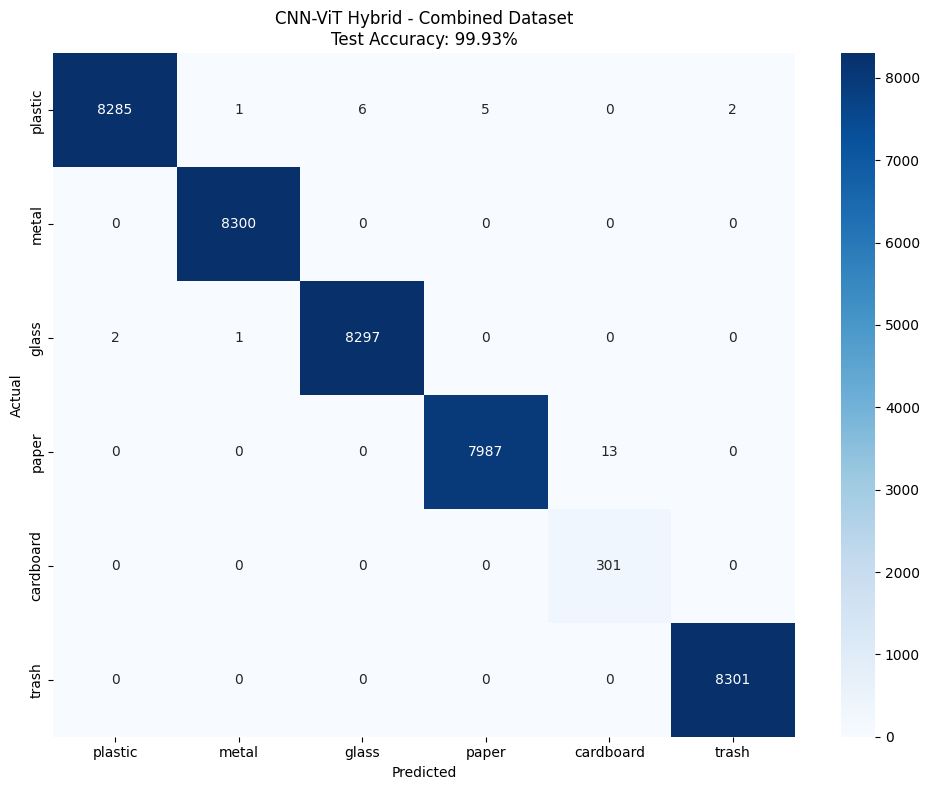


📈 TRAINING VISUALIZATION


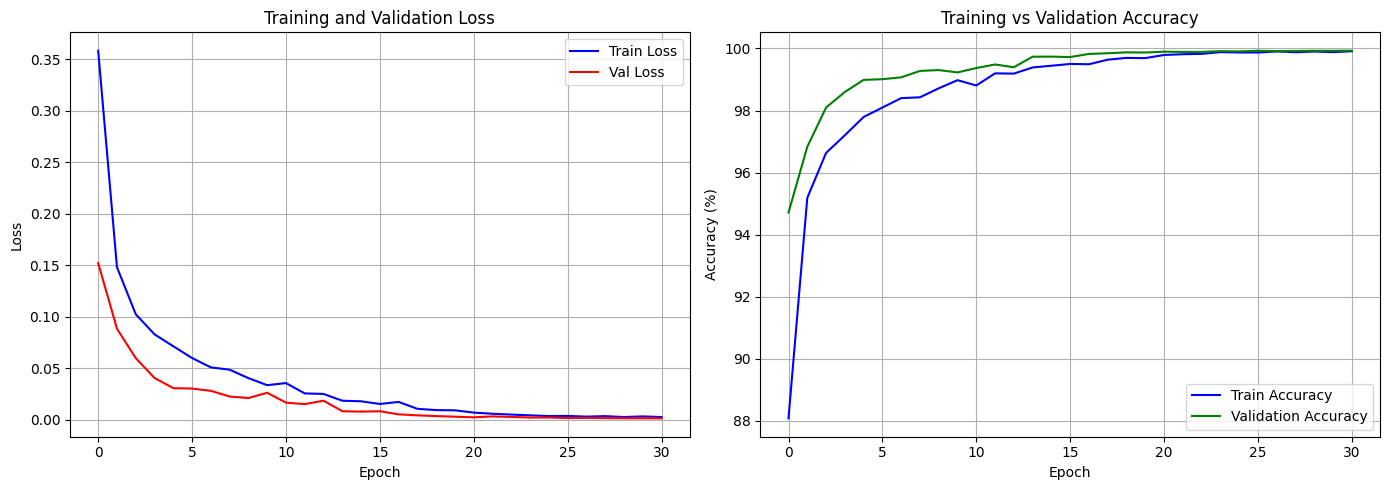


📈 ROC CURVE


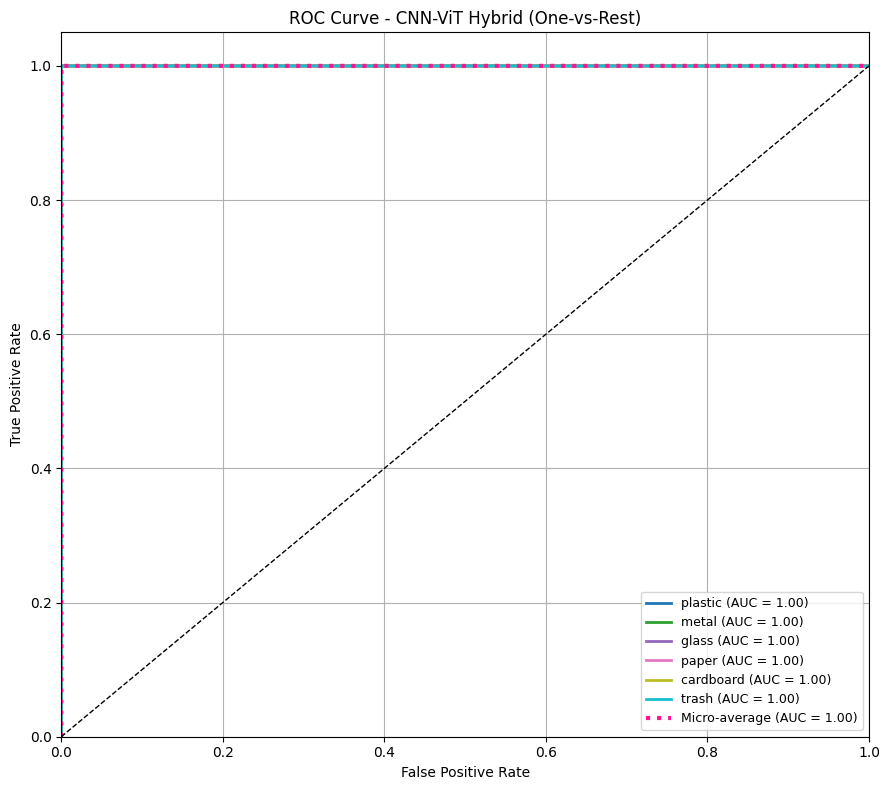


📊 DATASET STATISTICS

Class Distribution (Combined Dataset):
  plastic: 8299 images (20.0%)
  metal: 8300 images (20.0%)
  glass: 8300 images (20.0%)
  paper: 8000 images (19.3%)
  cardboard: 301 images (0.7%)
  trash: 8301 images (20.0%)

📈 Per-Class Test Accuracy:
  plastic: 99.8% (8285/8299)
  metal: 100.0% (8300/8300)
  glass: 100.0% (8297/8300)
  paper: 99.8% (7987/8000)
  cardboard: 100.0% (301/301)
  trash: 100.0% (8301/8301)

💾 SAVING MODEL
✅ Model saved as 'cnn_vit_hybrid_6class.pth'
   Test Accuracy: 99.93%
   Best Val Accuracy: 99.93%
✅ Label encoder saved

🎯 INFERENCE FUNCTION

Example inference:

# To predict a single image:
class_name, confidence = predict_image(
    image_path='path/to/test_image.jpg',
    model=model,
    label_encoder=label_encoder,
    transform=val_transform,
    device=DEVICE
)
print(f"Prediction: {class_name} (Confidence: {confidence:.1f}%)")


🎉 CNN-ViT HYBRID TRAINING COMPLETE!

📊 FINAL RESULTS:
   Model: CNN (ResNet50) + ViT (DeiT-Small)
   Dat

In [1]:
import os
import numpy as np
import pickle
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. CONFIGURATION
# ============================================
# Paths to your datasets
UWCD_PATH = "/kaggle/input/datasets/siddhantmaji/unified-waste-classification-dataset/content/unified_dataset"
CUSTOM_PATH = "/kaggle/input/datasets/hadihebrewshuudu/wasteclass/WasteClassifiaction"

BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Early stopping settings
EARLY_STOPPING_PATIENCE = 10      # epochs to wait for val_loss improvement before stopping
EARLY_STOPPING_MIN_DELTA = 0.001  # minimum change in val_loss to count as improvement

# Checkpointing (so a killed Kaggle session - 9-12hr cap, GPU quota, disconnect - doesn't lose progress)
CHECKPOINT_PATH = '/kaggle/working/checkpoint_latest.pth'
CHECKPOINT_EVERY_N_EPOCHS = 1  # save every epoch; cheap relative to an epoch's compute cost

# Define your 6 target classes
TARGET_CLASSES = ['plastic', 'metal', 'glass', 'paper', 'cardboard', 'trash']

# Define mapping from UWCD classes to your target classes
UWCD_CLASS_MAPPING = {
    'plastic': 'plastic',
    'metal': 'metal', 
    'glass': 'glass',
    'paper_cardboard': 'paper',  # Map to paper class
    'trash': 'trash',
    # Ignore these classes:
    'biological': None,
    'battery': None,
    'clothes': None,
    'shoes': None
}

print("="*70)
print("🎯 CNN-ViT HYBRID - Combined Dataset (6 Classes)")
print("="*70)
print(f"Device: {DEVICE}")
print(f"Target Classes: {TARGET_CLASSES}")
print(f"UWCD Path: {UWCD_PATH}")
print(f"Custom Path: {CUSTOM_PATH}")

# ============================================
# 2. SMART DATASET CLASS WITH CLASS MAPPING
# ============================================
class SmartUnifiedDataset(Dataset):
    """
    Dataset class that handles both datasets with class mapping
    """
    def __init__(self, root_dir, target_classes, class_mapping=None, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.target_classes = target_classes
        self.class_to_idx = {cls: idx for idx, cls in enumerate(target_classes)}
        
        self.images = []
        self.labels = []
        
        if not os.path.exists(root_dir):
            print(f"⚠️ Warning: Path not found: {root_dir}")
            return
        
        print(f"\n📂 Loading from: {root_dir}")
        
        # Get all subdirectories (classes) in the dataset
        available_classes = [d for d in os.listdir(root_dir) 
                           if os.path.isdir(os.path.join(root_dir, d))]
        
        print(f"  Available classes: {available_classes}")
        
        # Process each class
        for class_name in available_classes:
            class_path = os.path.join(root_dir, class_name)
            
            # Determine target class name
            if class_mapping and class_name in class_mapping:
                target_class = class_mapping[class_name]
            else:
                target_class = class_name
            
            # Skip if target class is None (ignore) or not in our target classes
            if target_class is None or target_class not in target_classes:
                print(f"  ⏭️ Skipping: {class_name} (not in target classes)")
                continue
            
            # Get all image files
            img_files = [f for f in os.listdir(class_path) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
            
            # Add to dataset
            target_idx = self.class_to_idx[target_class]
            for img_name in img_files:
                self.images.append(os.path.join(class_path, img_name))
                self.labels.append(target_idx)
            
            print(f"  ✅ {class_name} → {target_class}: {len(img_files)} images")
        
        print(f"  Total: {len(self.images)} images")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return self.__getitem__((idx + 1) % len(self.images))
        
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# ============================================
# 3. DATA TRANSFORMS
# ============================================
print("\n" + "="*70)
print("📊 DATA PREPROCESSING")
print("="*70)

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("✅ Training transforms: with augmentation")
print("✅ Validation transforms: without augmentation")

# ============================================
# 4. LOAD AND COMBINE DATASETS
# ============================================
print("\n" + "="*70)
print("📊 LOADING AND COMBINING DATASETS")
print("="*70)

# NOTE: each dataset is now built exactly once per split (train/val/test) instead
# of also building a throwaway pair up front just for a print summary. The old
# code built uwcd_dataset/custom_dataset/combined_dataset AND uwcd_train/val/test
# AND custom_train/val/test - 8 full dataset scans of the same files. That
# redundant memory (plus num_workers forking 3 loaders) is a common cause of
# Kaggle's "tried to allocate more memory than is available" kernel restart.
print("\n🔄 Building datasets (one pass per split)...")

uwcd_train = SmartUnifiedDataset(UWCD_PATH, TARGET_CLASSES, UWCD_CLASS_MAPPING, transform=train_transform)
uwcd_val = SmartUnifiedDataset(UWCD_PATH, TARGET_CLASSES, UWCD_CLASS_MAPPING, transform=val_transform)
uwcd_test = SmartUnifiedDataset(UWCD_PATH, TARGET_CLASSES, UWCD_CLASS_MAPPING, transform=val_transform)

custom_train = SmartUnifiedDataset(CUSTOM_PATH, TARGET_CLASSES, None, transform=train_transform)
custom_val = SmartUnifiedDataset(CUSTOM_PATH, TARGET_CLASSES, None, transform=val_transform)
custom_test = SmartUnifiedDataset(CUSTOM_PATH, TARGET_CLASSES, None, transform=val_transform)

if len(uwcd_train) == 0 and len(custom_train) == 0:
    raise ValueError("No data loaded! Please check your dataset paths.")

# Combine
combined_train = ConcatDataset([uwcd_train, custom_train])
combined_val = ConcatDataset([uwcd_val, custom_val])
combined_test = ConcatDataset([uwcd_test, custom_test])

print(f"\n✅ Combined dataset total: {len(combined_train)} images")
print(f"   UWCD: {len(uwcd_train)} images")
print(f"   Custom: {len(custom_train)} images")

# Create data loaders
# num_workers reduced on val/test loaders since they don't need as much
# parallelism as train and each worker forks a copy of the process (RAM cost).
#
# CLASS IMBALANCE FIX: cardboard only comes from the custom dataset (UWCD's
# paper_cardboard is mapped entirely into "paper"), so cardboard is
# underrepresented per epoch versus paper. A WeightedRandomSampler fixes this
# by sampling rare classes more often - it does NOT duplicate/delete any files,
# it only changes how often each image gets picked into a batch. This is only
# applied to the TRAINING loader; val/test keep their natural distribution so
# accuracy numbers still reflect real-world class balance.
# NOTE: this intentionally changes training dynamics (that's the point of
# fixing an imbalance) - expect cardboard accuracy to improve, and other
# per-class numbers to shift slightly as gradient attention is redistributed.
USE_WEIGHTED_SAMPLING = True

train_labels = uwcd_train.labels + custom_train.labels  # matches ConcatDataset([uwcd_train, custom_train]) order

if USE_WEIGHTED_SAMPLING:
    class_sample_counts = np.bincount(train_labels, minlength=len(TARGET_CLASSES))
    print("\n⚖️ Class counts in training data (before balancing):")
    for cls, cnt in zip(TARGET_CLASSES, class_sample_counts):
        print(f"  {cls}: {cnt}")

    class_weights_for_sampling = 1.0 / np.maximum(class_sample_counts, 1)
    sample_weights = [class_weights_for_sampling[label] for label in train_labels]
    train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_labels), replacement=True)

    # sampler and shuffle are mutually exclusive in DataLoader - sampler already randomizes order
    train_loader = DataLoader(combined_train, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=2)
    print("✅ WeightedRandomSampler enabled - each class now sampled ~equally per epoch")
else:
    train_loader = DataLoader(combined_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

val_loader = DataLoader(combined_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(combined_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n📊 Dataset Split:")
print(f"  Training:   {len(combined_train)} images")
print(f"  Validation: {len(combined_val)} images")
print(f"  Test:       {len(combined_test)} images")

# ============================================
# 5. CNN-ViT HYBRID MODEL (FIXED - CORRECT CLASS NAME)
# ============================================
print("\n" + "="*70)
print("🧠 BUILDING CNN-ViT HYBRID MODEL")
print("="*70)

class CNNViTHybrid(nn.Module):
    """
    Hybrid model combining CNN and Vision Transformer features
    """
    def __init__(self, num_classes=6, cnn_model='resnet50', vit_model='deit_small_patch16_224'):
        super(CNNViTHybrid, self).__init__()
        
        print(f"\nInitializing CNN ({cnn_model}) + ViT ({vit_model})...")
        
        # CNN Branch (for local features)
        self.cnn = timm.create_model(cnn_model, pretrained=True)
        
        # Remove classifier head
        if hasattr(self.cnn, 'fc'):
            in_features_cnn = self.cnn.fc.in_features
            self.cnn.fc = nn.Identity()
        elif hasattr(self.cnn, 'classifier'):
            in_features_cnn = self.cnn.classifier.in_features
            self.cnn.classifier = nn.Identity()
        else:
            in_features_cnn = 2048  # Default for ResNet50
        
        # ViT Branch (for global features)
        self.vit = timm.create_model(vit_model, pretrained=True)
        
        # Remove classifier head
        if hasattr(self.vit, 'head'):
            in_features_vit = self.vit.head.in_features
            self.vit.head = nn.Identity()
        elif hasattr(self.vit, 'fc'):
            in_features_vit = self.vit.fc.in_features
            self.vit.fc = nn.Identity()
        else:
            in_features_vit = 384  # Default for deit_small
        
        print(f"  CNN features: {in_features_cnn}")
        print(f"  ViT features: {in_features_vit}")
        
        # Fusion layer
        fusion_dim = 512
        self.fusion = nn.Sequential(
            nn.Linear(in_features_cnn + in_features_vit, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
        self.num_classes = num_classes
        
        print(f"✅ Model built successfully!")
        print(f"   Total parameters: {sum(p.numel() for p in self.parameters()):,}")
    
    def forward(self, x):
        # Extract CNN features
        cnn_features = self.cnn(x)
        
        # Extract ViT features
        vit_features = self.vit(x)
        
        # Concatenate features
        combined = torch.cat([cnn_features, vit_features], dim=1)
        
        # Fusion
        fused = self.fusion(combined)
        
        # Classification
        output = self.classifier(fused)
        
        return output

# Initialize model
model = CNNViTHybrid(
    num_classes=len(TARGET_CLASSES),
    cnn_model='resnet50',
    vit_model='deit_small_patch16_224'
).to(DEVICE)

# Use both GPUs on Kaggle's T4 x2 if available.
# nn.DataParallel splits each batch across the visible GPUs and gathers results -
# no other code changes needed elsewhere in the script since we always call
# model(...) the same way. NOTE: model.state_dict() gets a "module." prefix
# when wrapped, so saving/loading is handled via a small helper below.
NUM_GPUS = torch.cuda.device_count()
if NUM_GPUS > 1:
    print(f"\n🚀 {NUM_GPUS} GPUs detected — wrapping model in nn.DataParallel")
    model = nn.DataParallel(model)
else:
    print(f"\nℹ️ {NUM_GPUS} GPU detected — running on a single device")

def get_model_state(m):
    """Return a state_dict without the 'module.' prefix, regardless of DataParallel wrapping."""
    return m.module.state_dict() if isinstance(m, nn.DataParallel) else m.state_dict()

def load_model_state(m, state_dict):
    """Load a state_dict into m, handling DataParallel wrapping transparently."""
    target = m.module if isinstance(m, nn.DataParallel) else m
    target.load_state_dict(state_dict)

print(f"\n📊 Model Architecture:")
print(f"  Device: {DEVICE}")
print(f"  Classes: {len(TARGET_CLASSES)}")

# ============================================
# 6. TRAINING SETUP
# ============================================
print("\n" + "="*70)
print("🎯 TRAINING SETUP")
print("="*70)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer with weight decay
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning rate scheduler
# NOTE: T_max is intentionally kept at the ORIGINAL epoch budget (30), not NUM_EPOCHS.
# If T_max were set to NUM_EPOCHS (100), the LR would decay much more slowly, so a run
# that early-stops around epoch 20-30 would train at a higher LR than the original
# 30-epoch run did at that same point - changing results, not just runtime.
LR_SCHEDULE_T_MAX = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=LR_SCHEDULE_T_MAX)

# Training metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print(f"Optimizer: AdamW (lr={LEARNING_RATE})")
print(f"Scheduler: CosineAnnealingLR")
print(f"Loss: CrossEntropyLoss")
print(f"Epochs: {NUM_EPOCHS} (max, with early stopping)")
print(f"Early Stopping: patience={EARLY_STOPPING_PATIENCE}, min_delta={EARLY_STOPPING_MIN_DELTA}")

# ============================================
# 7. TRAINING LOOP
# ============================================
print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

best_val_acc = 0
best_model_state = None
best_val_loss = float('inf')
epochs_no_improve = 0
start_epoch = 0

# Resume from checkpoint if one exists (e.g. previous session was killed by
# Kaggle's runtime cap, GPU quota, or a disconnect)
if os.path.exists(CHECKPOINT_PATH):
    print(f"\n🔄 Found checkpoint at {CHECKPOINT_PATH} — resuming...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    load_model_state(model, ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    train_losses = ckpt['train_losses']
    val_losses = ckpt['val_losses']
    train_accuracies = ckpt['train_accuracies']
    val_accuracies = ckpt['val_accuracies']
    best_val_acc = ckpt['best_val_acc']
    best_model_state = ckpt['best_model_state']
    best_val_loss = ckpt['best_val_loss']
    epochs_no_improve = ckpt['epochs_no_improve']
    print(f"   Resuming from epoch {start_epoch+1}/{NUM_EPOCHS} "
          f"(best_val_acc so far: {best_val_acc:.2f}%)")
else:
    print("\n▶️ No checkpoint found — starting fresh training run.")

for epoch in range(start_epoch, NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f}")
    
    train_acc = 100. * correct / total
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    
    # Validation phase
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_acc = 100. * correct / total
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    
    # Update learning rate
    scheduler.step()
    
    # Save best model (based on validation accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = get_model_state(model).copy()
        print(f"✨ New best model! Val Acc: {val_acc:.2f}%")
    
    # Print epoch summary
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping check (based on validation loss plateau / overfitting signal)
    if avg_val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"  ⏳ No val_loss improvement for {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} epochs")

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1} "
              f"(no val_loss improvement for {EARLY_STOPPING_PATIENCE} epochs).")
        print("   This usually means the model has either converged or started overfitting.")
        # Save final checkpoint before breaking so state is consistent
        torch.save({
            'epoch': epoch,
            'model_state_dict': get_model_state(model),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies,
            'best_val_acc': best_val_acc,
            'best_model_state': best_model_state,
            'best_val_loss': best_val_loss,
            'epochs_no_improve': epochs_no_improve,
        }, CHECKPOINT_PATH)
        break

    # Save checkpoint (every epoch by default) so a killed session can resume
    if (epoch + 1) % CHECKPOINT_EVERY_N_EPOCHS == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': get_model_state(model),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accuracies': train_accuracies,
            'val_accuracies': val_accuracies,
            'best_val_acc': best_val_acc,
            'best_model_state': best_model_state,
            'best_val_loss': best_val_loss,
            'epochs_no_improve': epochs_no_improve,
        }, CHECKPOINT_PATH)
        print(f"  💾 Checkpoint saved (epoch {epoch+1})")

    print("-" * 70)

# Load best model
load_model_state(model, best_model_state)
print(f"\n✅ Training complete! Best validation accuracy: {best_val_acc:.2f}%")
print(f"   Actual epochs run: {len(train_losses)} / {NUM_EPOCHS}")

# ============================================
# 8. TEST EVALUATION
# ============================================
print("\n" + "="*70)
print("📊 TEST SET EVALUATION")
print("="*70)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

# Calculate accuracy
test_acc = accuracy_score(all_labels, all_preds) * 100
print(f"\n🎯 Test Accuracy: {test_acc:.2f}%")

# Classification report
print("\n📋 Per-Class Classification Report:")
print(classification_report(all_labels, all_preds, 
                          target_names=TARGET_CLASSES))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_CLASSES,
            yticklabels=TARGET_CLASSES)
plt.title(f'CNN-ViT Hybrid - Combined Dataset\nTest Accuracy: {test_acc:.2f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_combined_6class.png', dpi=300)
plt.show()

# ============================================
# 9. TRAINING CURVES (Loss + Train vs Val Accuracy)
# ============================================
print("\n" + "="*70)
print("📈 TRAINING VISUALIZATION")
print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Val Loss', color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curves (train vs validation)
ax2.plot(train_accuracies, label='Train Accuracy', color='blue')
ax2.plot(val_accuracies, label='Validation Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves_6class.png', dpi=300)
plt.show()

# ============================================
# 9b. ROC CURVE (One-vs-Rest, multiclass)
# ============================================
print("\n" + "="*70)
print("📈 ROC CURVE")
print("="*70)

n_classes = len(TARGET_CLASSES)
labels_binarized = label_binarize(all_labels, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(labels_binarized[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(labels_binarized.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(9, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{TARGET_CLASSES[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', lw=3,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN-ViT Hybrid (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve_6class.png', dpi=300)
plt.show()

# ============================================
# 10. DATASET STATISTICS
# ============================================
print("\n" + "="*70)
print("📊 DATASET STATISTICS")
print("="*70)

# Count images per class in combined dataset
# (uwcd_train/custom_train have the identical images+labels as the old
# uwcd_dataset/custom_dataset would have - only the transform differs, which
# doesn't affect counts - so no duplicate dataset load is needed here.)
class_counts = {class_name: 0 for class_name in TARGET_CLASSES}

for dataset in [uwcd_train, custom_train]:
    for label in dataset.labels:
        class_name = TARGET_CLASSES[label]
        class_counts[class_name] += 1

total_images = len(combined_train)
print("\nClass Distribution (Combined Dataset):")
for class_name in TARGET_CLASSES:
    count = class_counts[class_name]
    percentage = (count / total_images) * 100
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

# Per-class test accuracy
print("\n📈 Per-Class Test Accuracy:")
for i, class_name in enumerate(TARGET_CLASSES):
    correct = cm[i, i]
    total = cm[i, :].sum()
    acc = correct / total * 100
    print(f"  {class_name}: {acc:.1f}% ({correct}/{total})")

# ============================================
# 11. SAVE MODEL
# ============================================
print("\n" + "="*70)
print("💾 SAVING MODEL")
print("="*70)

# Save model checkpoint
checkpoint = {
    'model_state_dict': best_model_state,
    'classes': TARGET_CLASSES,
    'test_accuracy': test_acc,
    'best_val_accuracy': best_val_acc,
    'config': {
        'cnn_model': 'resnet50',
        'vit_model': 'deit_small_patch16_224',
        'image_size': IMAGE_SIZE,
        'num_classes': len(TARGET_CLASSES)
    }
}

torch.save(checkpoint, 'cnn_vit_hybrid_6class.pth')
print(f"✅ Model saved as 'cnn_vit_hybrid_6class.pth'")
print(f"   Test Accuracy: {test_acc:.2f}%")
print(f"   Best Val Accuracy: {best_val_acc:.2f}%")

# Save label encoder
label_encoder = LabelEncoder()
label_encoder.fit(TARGET_CLASSES)
with open('label_encoder_6class.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("✅ Label encoder saved")

# ============================================
# 12. INFERENCE FUNCTION
# ============================================
print("\n" + "="*70)
print("🎯 INFERENCE FUNCTION")
print("="*70)

def predict_image(image_path, model, label_encoder, transform, device):
    """
    Predict class for a single image
    """
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, prediction = torch.max(probabilities, 1)
    
    # Get class name
    class_name = label_encoder.inverse_transform([prediction.cpu().numpy()])[0]
    confidence_score = confidence.cpu().numpy()[0] * 100
    
    return class_name, confidence_score

print("\nExample inference:")
print("""
# To predict a single image:
class_name, confidence = predict_image(
    image_path='path/to/test_image.jpg',
    model=model,
    label_encoder=label_encoder,
    transform=val_transform,
    device=DEVICE
)
print(f"Prediction: {class_name} (Confidence: {confidence:.1f}%)")
""")

# ============================================
# 13. FINAL SUMMARY
# ============================================
print("\n" + "="*70)
print("🎉 CNN-ViT HYBRID TRAINING COMPLETE!")
print("="*70)

print(f"""
📊 FINAL RESULTS:
   Model: CNN (ResNet50) + ViT (DeiT-Small)
   Dataset: Combined (UWCD + Custom)
   Classes: {len(TARGET_CLASSES)} ({', '.join(TARGET_CLASSES)})
   
   Test Accuracy: {test_acc:.2f}%
   Best Validation: {best_val_acc:.2f}%
   
   Epochs Run: {len(train_losses)} / {NUM_EPOCHS} (max)
   Batch Size: {BATCH_SIZE}
   Learning Rate: {LEARNING_RATE}

📊 DATASET INFO:
   Total Images: {len(combined_train)}
   UWCD Images: {len(uwcd_train)} (paper_cardboard → paper)
   Custom Images: {len(custom_train)} (paper & cardboard separate)

💾 SAVED FILES:
   ✓ cnn_vit_hybrid_6class.pth (model weights)
   ✓ label_encoder_6class.pkl (class mapping)
   ✓ confusion_matrix_combined_6class.png
   ✓ training_curves_6class.png (loss + train vs val accuracy)
   ✓ roc_curve_6class.png (one-vs-rest multiclass ROC)

🚀 NEXT STEPS:
   1. Test on new images using predict_image()
   2. Monitor paper vs cardboard confusion
   3. Fine-tune hyperparameters for better accuracy
""")